In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries Imported Successfully")

✅ Libraries Imported Successfully


In [44]:
import pandas as pd

df = pd.read_csv("tesla_deliveries_dataset_2015_2025.csv")

print("✅ Dataset Loaded Successfully")
print("Rows:", data.shape[0])
print("Columns:", data.shape[1])

✅ Dataset Loaded Successfully
Rows: 2640
Columns: 12


In [45]:
data.head()

,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


In [46]:
print("Columns:")
for col in data.columns:
    print(col)

Columns:
Year
Month
Region
Model
Estimated_Deliveries
Production_Units
Avg_Price_USD
Battery_Capacity_kWh
Range_km
CO2_Saved_tons
Source_Type
Charging_Stations


In [47]:
print("Missing values in dataset:")
print(data.isna().sum())

print("Duplicate rows =", data.duplicated().sum())

Missing values in dataset:
Year                    0
Month                   0
Region                  0
Model                   0
Estimated_Deliveries    0
Production_Units        0
Avg_Price_USD           0
Battery_Capacity_kWh    0
Range_km                0
CO2_Saved_tons          0
Source_Type             0
Charging_Stations       0
dtype: int64
Duplicate rows = 0


In [48]:
print("Dataset Shape:", data.shape)

print("\nFirst 5 Rows:")
data.head()

Dataset Shape: (2640, 12)

First 5 Rows:


,Year,Month,Region,Model,Estimated_Deliveries,Production_Units,Avg_Price_USD,Battery_Capacity_kWh,Range_km,CO2_Saved_tons,Source_Type,Charging_Stations
0,2023,5,1,2,17646,17922,92874.27,120,704,1863.42,1,12207
1,2015,2,0,3,3797,4164,62205.65,75,438,249.46,2,7640
2,2019,1,3,3,8411,9189,117887.32,82,480,605.59,1,14071
3,2021,2,3,1,6555,7311,89294.91,120,712,700.07,2,9333
4,2016,12,2,4,12374,13537,114846.78,120,661,1226.88,0,8722


Year Wise Average Price
Year
2015    85684.351167
2016    84776.998500
2017    85111.401667
2018    86111.865917
2019    83990.488833
2020    84159.935375
2021    83270.606125
2022    85680.589208
2023    84509.945625
2024    85999.219375
2025    84685.341833
Name: Avg_Price_USD, dtype: float64


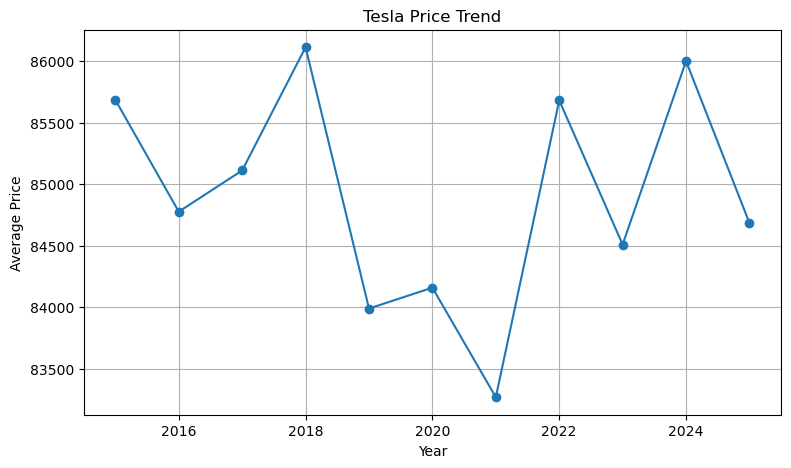

In [49]:
price_trend = data.groupby('Year')['Avg_Price_USD'].mean()

print("Year Wise Average Price")
print(price_trend)

plt.figure(figsize=(9,5))
plt.plot(price_trend.index, price_trend.values, marker='o')

plt.xlabel("Year")
plt.ylabel("Average Price")
plt.title("Tesla Price Trend")
plt.grid()

plt.show()

Year
2015    2375267
2016    2434081
2017    2350517
2018    2423104
2019    2404230
2020    2280336
2021    2335116
2022    2434220
2023    2382375
2024    2406899
2025    2368462
Name: Estimated_Deliveries, dtype: int64


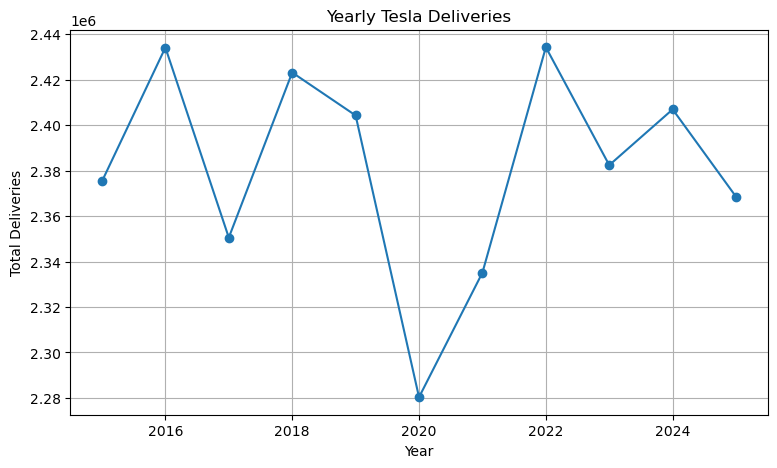

In [50]:
total_delivery = data.groupby('Year')['Estimated_Deliveries'].sum()

print(total_delivery)

plt.figure(figsize=(9,5))
plt.plot(total_delivery.index, total_delivery.values, 'o-')

plt.xlabel("Year")
plt.ylabel("Total Deliveries")
plt.title("Yearly Tesla Deliveries")

plt.grid()
plt.show()

Model
2    5380385
1    5321919
4    5225284
3    5157240
0    5109779
Name: Estimated_Deliveries, dtype: int64


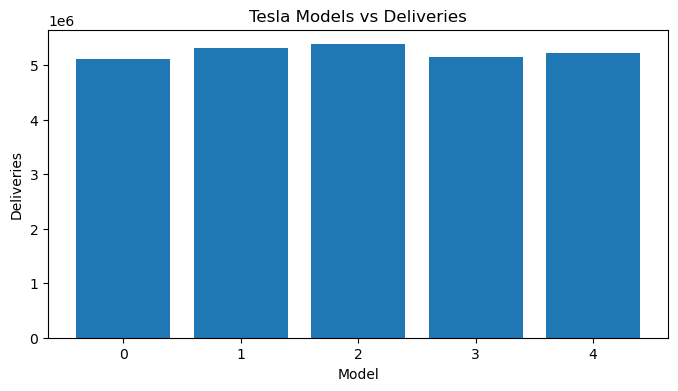

In [51]:
model_delivery = data.groupby("Model")["Estimated_Deliveries"].sum().sort_values(ascending=False)

print(model_delivery)

plt.figure(figsize=(8,4))
plt.bar(model_delivery.index, model_delivery.values)

plt.xlabel("Model")
plt.ylabel("Deliveries")
plt.title("Tesla Models vs Deliveries")

plt.show()

Average Price of Tesla Models
Model
4    86081.211061
2    85185.401269
1    84528.004223
0    84498.872159
3    84243.212936
Name: Avg_Price_USD, dtype: float64


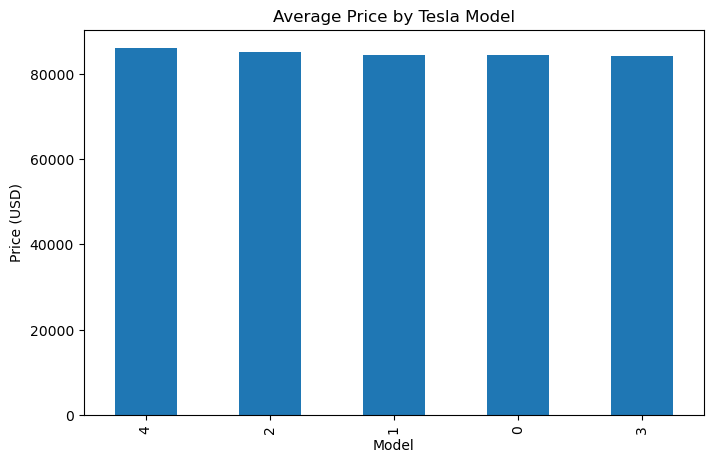

In [52]:
price_by_model = data.groupby('Model')['Avg_Price_USD'].mean().sort_values(ascending=False)

print("Average Price of Tesla Models")
print(price_by_model)

plt.figure(figsize=(8,5))

price_by_model.plot(kind='bar')

plt.title("Average Price by Tesla Model")
plt.xlabel("Model")
plt.ylabel("Price (USD)")

plt.show()

In [53]:
selected_features = data[[
    'Estimated_Deliveries',
    'Production_Units',
    'Avg_Price_USD',
    'Battery_Capacity_kWh',
    'Range_km',
    'CO2_Saved_tons',
    'Charging_Stations'
]]

corr = selected_features.corr()

print(corr['Avg_Price_USD'].sort_values(ascending=False))

Avg_Price_USD           1.000000
Charging_Stations      -0.017790
Range_km               -0.017854
Battery_Capacity_kWh   -0.018203
Estimated_Deliveries   -0.027546
CO2_Saved_tons         -0.028523
Production_Units       -0.029263
Name: Avg_Price_USD, dtype: float64


In [54]:
region_data = data.groupby('Region')['Avg_Price_USD'].mean()

print("Average Tesla Price in Different Regions")
print(region_data.sort_values(ascending=False))

Average Tesla Price in Different Regions
Region
1    86107.731939
0    85161.733773
2    84535.999091
3    83823.896515
Name: Avg_Price_USD, dtype: float64


Region
Europe          NaN
Asia            NaN
Middle East     NaN
North America   NaN
Name: Avg_Price_USD, dtype: float64


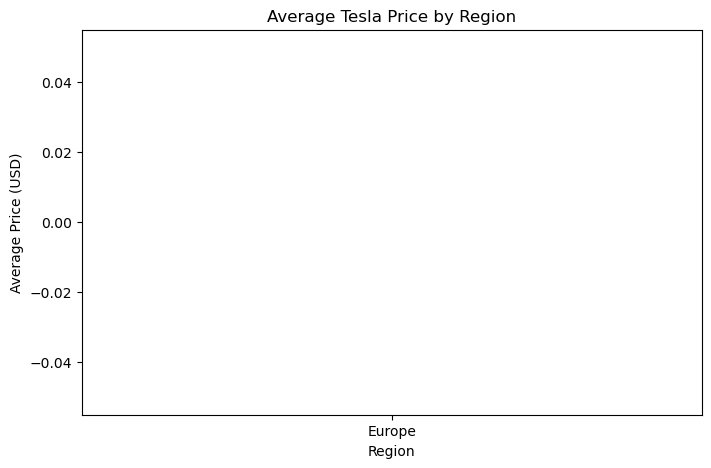

In [55]:
region_data = data.groupby('Region')['Avg_Price_USD'].mean()

custom_order = ['Europe', 'Asia', 'Middle East', 'North America']

region_data = region_data.reindex(custom_order)

print(region_data)

plt.figure(figsize=(8,5))
plt.bar(region_data.index, region_data.values)

plt.title("Average Tesla Price by Region")
plt.xlabel("Region")
plt.ylabel("Average Price (USD)")

plt.show()

In [56]:
from sklearn.preprocessing import LabelEncoder

le_region = LabelEncoder()
le_model = LabelEncoder()
le_source = LabelEncoder()

data['Region'] = le_region.fit_transform(data['Region'])
data['Model'] = le_model.fit_transform(data['Model'])
data['Source_Type'] = le_source.fit_transform(data['Source_Type'])

print("Encoding Done")

print("\nRegion Codes:")
print(data['Region'].unique())

print("\nModel Codes:")
print(data['Model'].unique())

print("\nSource Type Codes:")
print(data['Source_Type'].unique())

Encoding Done

Region Codes:
[1 0 3 2]

Model Codes:
[2 3 1 4 0]

Source Type Codes:
[1 2 0]


In [57]:
X = data.drop('Avg_Price_USD', axis=1)

y = data['Avg_Price_USD']

print("Feature Matrix Shape:", X.shape)
print("Target Shape:", y.shape)

print("\nTarget Variable:")
print(y.head())

Feature Matrix Shape: (2640, 11)
Target Shape: (2640,)

Target Variable:
0     92874.27
1     62205.65
2    117887.32
3     89294.91
4    114846.78
Name: Avg_Price_USD, dtype: float64


In [58]:
from sklearn.model_selection import train_test_split

# Target column
y = data['Estimated_Deliveries']

# Features
X = data.drop('Estimated_Deliveries', axis=1)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train-Test Split Completed")

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape :", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape :", y_test.shape)

Train-Test Split Completed
Training Data Shape: (2112, 11)
Testing Data Shape : (528, 11)
Training Target Shape: (2112,)
Testing Target Shape : (528,)


In [59]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X_train, y_train)

print("✅ Linear Regression Model Trained Successfully")

✅ Linear Regression Model Trained Successfully


In [60]:
from sklearn.linear_model import LinearRegression

# Train Model
model = LinearRegression()
model.fit(X_train, y_train)

# Prediction
predicted_values = model.predict(X_test)

print("Actual Price    Predicted Price")

for i in range(5):
    print(f"{y_test.iloc[i]:.2f}    {predicted_values[i]:.2f}")

Actual Price    Predicted Price
6991.00    7560.65
9326.00    9391.56
9061.00    8804.65
8951.00    9378.60
8707.00    8911.52


In [61]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_value = r2_score(y_test, predicted_values)
mae_value = mean_absolute_error(y_test, predicted_values)
rmse_value = np.sqrt(mean_squared_error(y_test, predicted_values))

print("Performance Metrics")
print("-------------------")
print("R2 Score :", round(r2_value, 4))
print("MAE      :", round(mae_value, 2))
print("RMSE     :", round(rmse_value, 2))

Performance Metrics
-------------------
R2 Score : 0.9901
MAE      : 310.13
RMSE     : 383.58


In [62]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)

print("✅✅✅ Random Forest Model Trained Successfully")

✅✅✅ Random Forest Model Trained Successfully


In [63]:
rf_predictions = rf.predict(X_test)

print("Sample Predictions")

for i in range(5):
    actual = y_test.iloc[i]
    predicted = rf_predictions[i]

    print(f"Actual: {actual:.2f}  Predicted: {predicted:.2f}")

Sample Predictions
Actual: 6991.00  Predicted: 7361.80
Actual: 9326.00  Predicted: 9357.63
Actual: 9061.00  Predicted: 8942.64
Actual: 8951.00  Predicted: 9422.18
Actual: 8707.00  Predicted: 8777.07


In [64]:
rf_predictions = rf.predict(X_test)

from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

print("R2 Score :", round(r2_score(y_test, rf_predictions), 4))
print("MAE      :", round(mean_absolute_error(y_test, rf_predictions), 2))
print("RMSE     :", round(np.sqrt(mean_squared_error(y_test, rf_predictions)), 2))

R2 Score : 0.9888
MAE      : 323.46
RMSE     : 409.5


In [65]:
corr_data = data.corr(numeric_only=True)

delivery_corr = corr_data['Estimated_Deliveries']

print(delivery_corr.sort_values(ascending=False))

Estimated_Deliveries    1.000000
Production_Units        0.994234
CO2_Saved_tons          0.836814
Month                   0.030877
Model                   0.004515
Charging_Stations       0.000753
Region                 -0.001206
Year                   -0.002863
Range_km               -0.006606
Battery_Capacity_kWh   -0.007765
Source_Type            -0.013190
Avg_Price_USD          -0.027546
Name: Estimated_Deliveries, dtype: float64


In [66]:
X = df.drop('Estimated_Deliveries', axis=1)

y = df['Estimated_Deliveries']

print("✅ New Target Variable Selected")

print("Feature Shape:", X.shape)
print("Target Shape :", y.shape)

print("\nTarget Preview:")
print(y.head())

✅ New Target Variable Selected
Feature Shape: (2640, 11)
Target Shape : (2640,)

Target Preview:
0    17646
1     3797
2     8411
3     6555
4    12374
Name: Estimated_Deliveries, dtype: int64


In [67]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("✅ New Train-Test Split Completed")

print("\nX_train Shape:", X_train.shape)
print("X_test Shape :", X_test.shape)

print("\ny_train Shape:", y_train.shape)
print("y_test Shape :", y_test.shape)

✅ New Train-Test Split Completed

X_train Shape: (2112, 11)
X_test Shape : (528, 11)

y_train Shape: (2112,)
y_test Shape : (528,)


In [71]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Region'] = le.fit_transform(data['Region'])
data['Model'] = le.fit_transform(data['Model'])
data['Source_Type'] = le.fit_transform(data['Source_Type'])

In [76]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

data['Region'] = encoder.fit_transform(data['Region'])

In [77]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data['Region'] = le.fit_transform(data['Region'])
data['Model'] = le.fit_transform(data['Model'])
data['Source_Type'] = le.fit_transform(data['Source_Type'])

In [78]:
# Create X and y again
X = data.drop('Estimated_Deliveries', axis=1)
y = data['Estimated_Deliveries']

# Train Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Train Model
from sklearn.linear_model import LinearRegression

lr_delivery = LinearRegression()
lr_delivery.fit(X_train, y_train)

# Predict
delivery_pred = lr_delivery.predict(X_test)

In [79]:
print("Actual Deliveries | Predicted Deliveries")

for i in range(5):
    print(f"{y_test.iloc[i]} | {round(delivery_pred[i])}")

Actual Deliveries | Predicted Deliveries
6991 | 7561
9326 | 9392
9061 | 8805
8951 | 9379
8707 | 8912


In [80]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np

r2_delivery = r2_score(y_test, delivery_pred)

mae_delivery = mean_absolute_error(y_test, delivery_pred)

rmse_delivery = np.sqrt(mean_squared_error(y_test, delivery_pred))

print("Delivery Prediction Performance")
print("-------------------------------")
print("R2 Score :", round(r2_delivery,4))
print("MAE      :", round(mae_delivery,2))
print("RMSE     :", round(rmse_delivery,2))

Delivery Prediction Performance
-------------------------------
R2 Score : 0.9901
MAE      : 310.13
RMSE     : 383.58


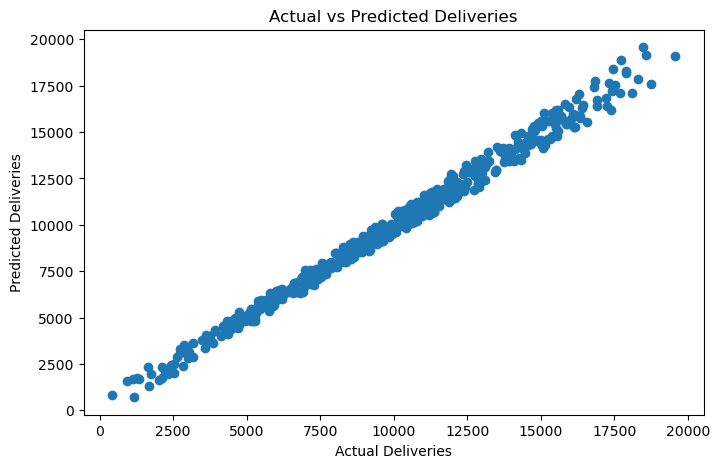

In [81]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, delivery_pred)

plt.xlabel("Actual Deliveries")
plt.ylabel("Predicted Deliveries")
plt.title("Actual vs Predicted Deliveries")

plt.show()

In [82]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': lr_delivery.coef_
})

coefficients = coefficients.sort_values(
    by='Coefficient',
    ascending=False
)

print(coefficients)

                 Feature  Coefficient
3                  Model     4.804767
8         CO2_Saved_tons     2.155679
6   Battery_Capacity_kWh     1.881709
1                  Month     1.445077
0                   Year     0.967453
4       Production_Units     0.768549
10     Charging_Stations     0.002224
5          Avg_Price_USD     0.000453
2                 Region    -3.399724
7               Range_km    -3.629959
9            Source_Type    -3.976727


In [83]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rf = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10]
}

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)

print("\nBest R2 Score:")
print(grid_search.best_score_)

Best Parameters:
{'max_depth': 10, 'n_estimators': 100}

Best R2 Score:
0.9880360164984637


In [84]:
yearly_data = df.groupby('Year')['Estimated_Deliveries'].sum().reset_index()

print(yearly_data)

    Year  Estimated_Deliveries
0   2015               2375267
1   2016               2434081
2   2017               2350517
3   2018               2423104
4   2019               2404230
5   2020               2280336
6   2021               2335116
7   2022               2434220
8   2023               2382375
9   2024               2406899
10  2025               2368462


In [85]:
from sklearn.linear_model import LinearRegression

X_year = yearly_data[['Year']]
y_year = yearly_data['Estimated_Deliveries']

forecast_model = LinearRegression()

forecast_model.fit(X_year, y_year)

print("✅ Forecast Model Trained Successfully")

✅ Forecast Model Trained Successfully


In [86]:
future_years = pd.DataFrame({
    'Year': [2026, 2027, 2028]
})

future_predictions = forecast_model.predict(future_years)

forecast_df = pd.DataFrame({
    'Year': [2026, 2027, 2028],
    'Forecasted_Deliveries': future_predictions.astype(int)
})

print(forecast_df)

   Year  Forecasted_Deliveries
0  2026                2376197
1  2027                2375342
2  2028                2374487


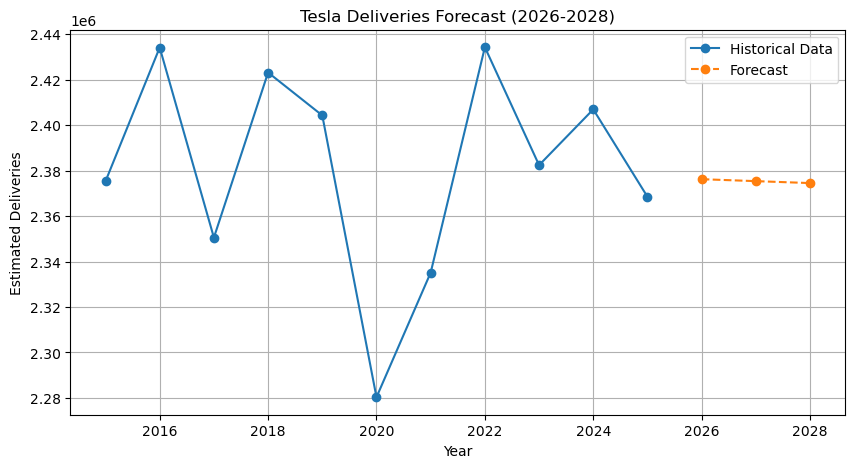

In [87]:
plt.figure(figsize=(10,5))

plt.plot(
    yearly_data['Year'],
    yearly_data['Estimated_Deliveries'],
    marker='o',
    label='Historical Data'
)

plt.plot(
    forecast_df['Year'],
    forecast_df['Forecasted_Deliveries'],
    marker='o',
    linestyle='--',
    label='Forecast'
)

plt.title("Tesla Deliveries Forecast (2026-2028)")
plt.xlabel("Year")
plt.ylabel("Estimated Deliveries")
plt.legend()
plt.grid(True)

plt.show()